# Task 2: Time Series Forecasting

## Guide Me in Finance (GMF) Investments

This notebook develops forecasting models for TSLA, BND, and SPY using historical market data prepared in Task 1.

Objectives:
- Prepare time series for forecasting
- Split data into training and testing sets
- Develop ARIMA forecasting models
- Evaluate forecasting accuracy
- Compare model performance

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

from math import sqrt

import yfinance as yf

In [2]:
start_date = "2015-01-01"
end_date = "2026-06-30"

tickers = ["TSLA", "BND", "SPY"]

data = {}

for ticker in tickers:
    df = yf.download(
        ticker,
        start=start_date,
        end=end_date,
        progress=False,
        auto_adjust=False
    )

    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.droplevel(1)

    data[ticker] = df

print("Data loaded successfully.")

Data loaded successfully.


In [3]:
closing_prices = {}

for ticker in tickers:
    closing_prices[ticker] = data[ticker]["Close"]

for ticker in tickers:
    print(f"{ticker}: {closing_prices[ticker].shape}")

TSLA: (2888,)
BND: (2888,)
SPY: (2888,)


In [4]:
train = {}
test = {}

for ticker in tickers:
    split_index = int(len(closing_prices[ticker]) * 0.8)

    train[ticker] = closing_prices[ticker][:split_index]
    test[ticker] = closing_prices[ticker][split_index:]

    print(
        f"{ticker}: "
        f"Train={len(train[ticker])}, "
        f"Test={len(test[ticker])}"
    )

TSLA: Train=2310, Test=578
BND: Train=2310, Test=578
SPY: Train=2310, Test=578


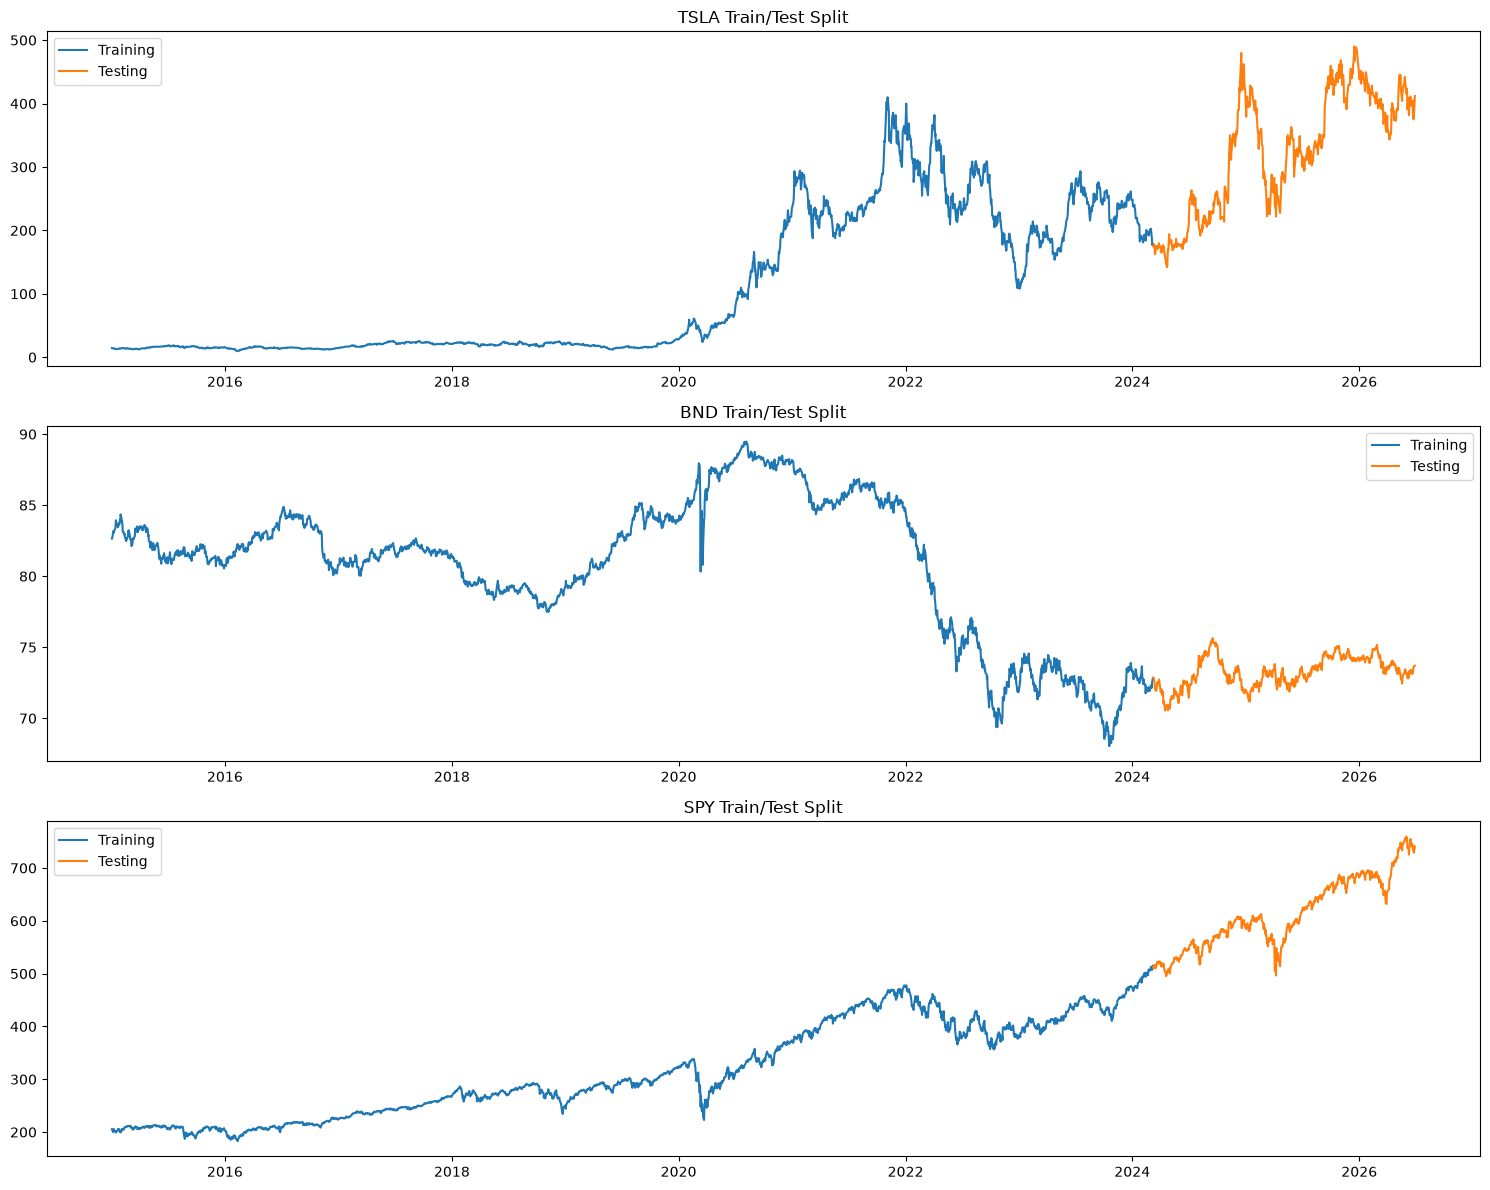

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

for ax, ticker in zip(axes, tickers):
    ax.plot(train[ticker], label="Training")
    ax.plot(test[ticker], label="Testing")

    ax.set_title(f"{ticker} Train/Test Split")
    ax.legend()

plt.tight_layout()
plt.show()